In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
# sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# Hermes-3 I/O

In [2]:

flg = Load.case_1D('/Users/lloyd/Documents/hermes_dir/hermes-3/build-minmod-geometry_1d/examples/tokamak-1D/TB_field_line_example', guard_replace = False, use_squash=True)
flg_ds = flg.ds.isel(t=-1)

base = Load.case_1D('/Users/lloyd/Documents/hermes_dir/hermes-3/build-minmod-geometry_1d/examples/tokamak-1D/1D-threshold', guard_replace = False, use_squash=True)
base_ds = base.ds.isel(t=-1)

- Looking for squash file
- Squash file found. squash date 11/03/2025, 09:34:18, dmp file date 11/03/2025, 09:26:18
- Looking for squash file
- Squash file found. squash date 11/02/2025, 19:30:40, dmp file date 10/28/2025, 14:34:41


In [3]:
print(flg_ds.data_vars)

Data variables:
    Bxy                                         (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_iz                                      (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_rec                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Ed_target_recycle                           (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Edd+_cx                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Fd+_iz                                      (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Fd+_rec                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Fdd+_cx                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    G1                                          (pos) float64 3kB dask.array<chunksize=(

In [4]:
from typing import Any


print(flg_ds['Te'].units)

def guard_replace_1d(da):
    da = da[1:-1]
    da[-1] = (da[-1] + da[-2])/2
    da[0] = (da[0] + da[1])/2
    return da



for var in ds.data_vars:
    if "pos" in ds[var].dims or "y" in ds[var].dims:
        ds[var] = guard_replace_1d(ds[var])




eV


NameError: name 'ds' is not defined

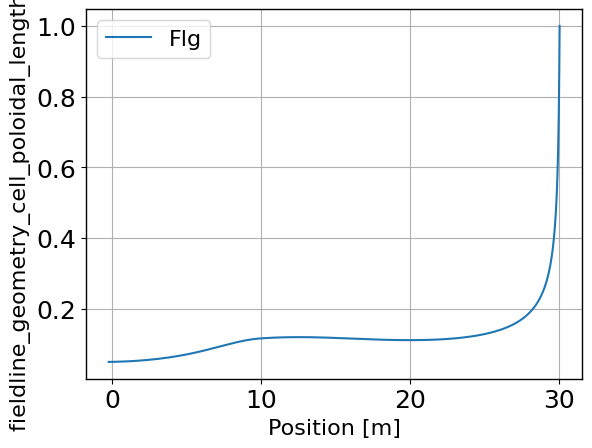

In [ ]:
fig, ax, =  plt.subplots()
var = 'fieldline_geometry_cell_poloidal_length'


ax.plot(flg_ds['pos'], (1/flg_ds[var])/np.max(1/flg_ds[var]), label='Flg')
# ax.plot(base_ds['pos'], base_ds[var], label='Base')
ax.set_xlabel('Position [m]')
ax.set_ylabel(f'{flg_ds[var].name}, {flg_ds[var].units}')
# ax.set_title('Flux expansion')
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
# ax.grid()
ax.legend()